In [2]:
import pandas as pd
import numpy as np

datfile = "./Experiment2.csv"
labelfile = "./KMTRICKS2MORPHO.tsv"

datorg = pd.read_csv(datfile,index_col=0)
dat = datorg.T

lab = pd.read_csv(labelfile, header=None, sep='\t')
labnames = lab.values[:,0:2]


In [4]:
mapping_dict = {'Wild':1, 'Cabbage':2,'acephala':3,'Broccoli': 4,'Cauliflower': 5}
#mapping_dict = {'Broccoli': 0,'Cauliflower': 1}
default_value=0

ynames = dat.axes[0].values
name2val = {}
for i in range(len(labnames)):
    def map_with_default(value):
        return mapping_dict.get(value, default_value)
    name2val[labnames[i,0]] = map_with_default(labnames[i,1])
def name2class(name):
    return name2val[name]

y = np.array(list(map(name2class,ynames)))

dat['Label'] = y


print(dat.shape)
print(y.shape,sum(y))

(215, 4006)
(215,) 708


In [ ]:
# Selecting the most correlated kmers .... 

import seaborn as sns
import matplotlib.pyplot as plt
X = dat.drop('Label',axis=1)
X = X.T
y = dat['Label']
corr2label = dat.corrwith(dat['Label'])
c2la = abs(corr2label)
#c2la = corr2label # To find the feature with the highest absolute correlation:
k = 11
topk_indices = np.argpartition(c2la, -k)[-k:].tolist()
topk_indices.sort(key = lambda x : c2la.iloc[x],reverse=True)

top_k_values = corr2label.iloc[topk_indices]
print(top_k_values)

topkfeatures = dat[dat.columns[topk_indices]]
topkfeatures.to_csv(f'top{k}features.csv')

correlation_matrix = topkfeatures.corr()
plt.figure(figsize=(8, 6)) # Adjust figure size if needed
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm', # A common colormap for correlation heatmaps
    fmt=".2f", # Format annotations to two decimal places
    square=True # Ensure cells are square
)
plt.title('Pairwise Correlation Heatmap')
plt.show()



In [ ]:
import numpy as np
import umap
import sklearn.datasets
import matplotlib.pyplot as plt

X = datorg



reducer = umap.UMAP(random_state=42, n_jobs=1) # Set random_state for reproducibility
embedding = reducer.fit_transform(X)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding[1:, 0],
    embedding[1:, 1],
    #c=y, # Color points by their target label (digit value)
    #cmap='Accent', # Use a visually distinct colormap
    s=5 # Adjust point size for better visibility, especially with large datasets
)
scatter = plt.scatter(
    embedding[:1, 0],
    embedding[:1, 1],

    s=50 # Adjust point size for better visibility, especially with large datasets
)


# Add a color bar and set ticks to correspond to digit labels (0-9)
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP projection of the Cabbage dataset', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sample data (replace with your actual data, X)
# For example, using the Iris dataset
X = datorg

# 2. Fit the PCA model
# You can set n_components to the total number of features to get all components' variance
pca = PCA(n_components=6)
embedding= pca.fit_transform(X)



# 3. Access the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# 4. Plot the "spectrum" (scree plot)
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, label='Individual explained variance')
plt.step(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('PCA Spectrum (Scree Plot)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding[1:, 0],
    embedding[1:, 1],
    #c=y, # Color points by their target label (digit value)
    cmap='Accent', # Use a visually distinct colormap
    s=5 # Adjust point size for better visibility, especially with large datasets
)
scatter = plt.scatter(
    embedding[:1, 0],
    embedding[:1, 1],

    s=50 # Adjust point size for better visibility, especially with large datasets
)


# Add a color bar and set ticks to correspond to digit labels (0-9)
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('PCA projection of the Cabbage dataset', fontsize=14)
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.show()


In [ ]:
# selecting the most complementary features to an existing one
def mostcomp(km : str):
    corr = dat[km].corr(dat['Label'])
    sign = np.sign(corr)
    #print(corr)
    mask = (dat[km] == dat['Label']) if sign <0 else (dat[km] != dat['Label'])
    df = dat.loc[mask]
    #dat.head()
    print(df.shape)
    corr2label = dat.corrwith(dat['Label'])
    c2la = abs(corr2label)
    # To find the feature with the highest absolute correlation:
    topk_indices = dat.columns[c2la>=0.95]
    print(f'Best complement to {km} are: {topk_indices}')


mostcomp('cluster8644')
mostcomp('cluster1651')
mostcomp('cluster10765')
mostcomp('cluster2041')


In [ ]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# number of most kmers dropped vs CV accuracy !
# check the classifiability of the remaining less correlated features

def droppedVsAccu(k):
    X = dat.drop('Label',axis=1)
    y = dat['Label']
    corr2label = dat.corrwith(dat['Label'])
    c2la = abs(corr2label)
    #c2la = corr2label
    # To find the feature with the highest absolute correlation:
    topk_indices = np.argpartition(c2la, -k)[-k:].tolist()
    topk_indices.sort(key = lambda x : c2la.iloc[x],reverse=True)
    top_k_values = corr2label.iloc[topk_indices]

    xgb_model = xgb.XGBClassifier(objective="binary:logistic", n_estimators=3, random_state=42, max_depth=2, eval_metric="logloss")
    model     = xgb.XGBClassifier(objective='binary:logistic', n_estimators=3, random_state=42, max_depth=2,  eval_metric='logloss')
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    X2 = dat.drop(dat.columns[topk_indices],axis=1)
    
    scores = cross_val_score(xgb_model, X2, y, cv=skf, scoring='accuracy')
    return scores.mean()

ks = [10,20,50,100,200,400]
dva =[droppedVsAccu(k) for k in ks]
plt.plot(ks, dva, marker='o')



In [ ]:
dat.head()

In [ ]:
#%%capture capoutput --no-stderr

import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold



skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = dat.drop(topk_indices, axis=1)

ind=np.array(['Label'])
xgb_model = xgb.XGBClassifier(objective="binary:logistic", n_estimators=3, random_state=42, max_depth=2, eval_metric="logloss")
model     = xgb.XGBClassifier(objective='binary:logistic', n_estimators=3, random_state=42, max_depth=2,  eval_metric='logloss')
t = 1
while True:
    # train xgboost to get meanAccu
    scores = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')
    print(scores.mean())
    
    if scores.mean()>0.95:
        model.fit(X,y)
        model.get_booster().feature_names = list(X.columns)
        importances = model.feature_importances_
        impFeatures = importances#[importances>=0.01]
        #print(impFeatures[0:10])
        indices = impFeatures.argsort()[::-1]
        #print(indices[0:10])
        feature_names = X.columns
        k = min(5,len(indices))
        if k==0: break 
        #print("Top {} most important features:".format(k))
        for i in range(k):
            print(f"{feature_names[indices[i]]}: {impFeatures[indices[i]]}")   
        ind=np.append(ind,feature_names[indices[0:k]],axis=0)
        X = dat.drop(ind, axis=1)
    else:
        break

with open('output2.txt', 'w') as f:
    f.write(capoutput.stdout)
print("Output successfully written to output.txt")


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

dtree = DecisionTreeClassifier(max_depth=2, random_state=42,min_samples_leaf=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = dat.drop(dat.columns[topk_indices],axis=1)
#X = dat.drop('Label',axis=1)
y = dat['Label']
count =0
while True:
    scores = cross_val_score(dt, X, y, cv=skf, scoring='accuracy')
    if scores.mean()>0.95:
        # build the model
        dtree.fit(X,y)
        print(export_text(dtree,feature_names=X.columns))
        
        if X.shape[1] <=1:
            break
        plt.figure(figsize=(15, 10)) # Adjust the figure size for better visibility
        plot_tree(dtree, 
          feature_names=X.columns,  # Use actual feature names
          #class_names=dat.target_names,    # Use actual class names
          filled=True,                      # Color the nodes by majority class
          rounded=True,                     # Use rounded node boxes
          precision=2,                      # Decimal precision for floats
          fontsize=10)                      # Adjust font size
        count +=1 
        
        idx = dtree.tree_.feature # set of features - remove to 
        X = X.drop(X.columns[idx],axis=1)
    else: break
print(f'Totally {count} number of trees generated')
plt.show() # Display the plot (mandatory in some environments like Windows)



In [77]:
import csv
CALkmer = []
with open("CALexp.csv", newline="", encoding="utf-8") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        CALkmer +=(row)
CALkmer=map(int,CALkmer)
print(CALkmer)

#X = dat.drop(dat.columns[topk_indices],axis=1)
X = dat[CALkmer]
X.head()


dtree = DecisionTreeClassifier(max_depth=2, random_state=42,min_samples_leaf=10)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


y = dat['Label']
count =0
while True:
    scores = cross_val_score(dt, X, y, cv=skf, scoring='accuracy')
    if scores.mean()>0.95:
        # build the model
        dtree.fit(X,y)
        print(export_text(dtree,feature_names=X.columns))
        
        if X.shape[1] <=1:
            break
        plt.figure(figsize=(15, 10)) # Adjust the figure size for better visibility
        plot_tree(dtree, 
          feature_names=X.columns,  # Use actual feature names
          #class_names=dat.target_names,    # Use actual class names
          filled=True,                      # Color the nodes by majority class
          rounded=True,                     # Use rounded node boxes
          precision=2,                      # Decimal precision for floats
          fontsize=10)                      # Adjust font size
        count +=1 
        
        idx = dtree.tree_.feature # set of features - remove to 
        X = X.drop(X.columns[idx],axis=1)
    else: break
print(f'Totally {count} number of trees generated')
plt.show() # Display the plot (mandatory in some environments like Windows)



KeyError: '[1710, 1719, 2468, 2469, 2510, 2521, 2559, 2730, 2904, 3236, 3340, 3609, 3610, 3618, 3822, 430, 4704, 4838, 52, 5245, 5809, 5841, 6351, 6450, 7052, 7255, 7314, 7817, 812, 813, 8323, 8550, 8629, 8989, 8996] not in index'

In [ ]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt

xgb_model = xgb.XGBClassifier(objective="binary:logistic", n_estimators=3, random_state=42, max_depth=2, eval_metric="logloss")
model     = xgb.XGBClassifier(objective='binary:logistic', n_estimators=3, random_state=42, max_depth=2,  eval_metric='logloss')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X2 = dat.drop(dat.columns[topk_indices],axis=1)
print(X2.shape)

scores = cross_val_score(xgb_model, X2, y, cv=skf, scoring='accuracy')


print(f"Cross-validation scores: {scores}")
print(f"Mean CV score: {scores.mean():.4f}")
print(f"Std of CV score: {scores.std():.4f}")

model.fit(X2,y)
model.get_booster().feature_names = list(X2.columns)

print(dat.columns[topk_indices])

importances = model.feature_importances_
feature_names = X2.columns
# 4. Sort by importance
sorted_indices = importances.argsort()[::-1]
top_n = 5
print("Top {} most important features:".format(top_n))
for i in range(top_n):
    print(f"{feature_names[sorted_indices[i]]}: {importances[sorted_indices[i]]}")

xgb.plot_importance(model.get_booster(), importance_type='gain', height=0.4)
plt.title('Feature Importance (Gain)')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree


dt = DecisionTreeClassifier(max_depth=2, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(dt, X2, y, cv=skf, scoring='accuracy')


print(f"Cross-validation scores: {scores}")
print(f"Mean CV score: {scores.mean():.4f}")
print(f"Std of CV score: {scores.std():.4f}")

dt.fit(X2,y)

plt.figure(figsize=(15, 10)) # Adjust the figure size for better visibility
plot_tree(dt, 
          feature_names=X2.columns,  # Use actual feature names
          #class_names=dat.target_names,    # Use actual class names
          filled=True,                      # Color the nodes by majority class
          rounded=True,                     # Use rounded node boxes
          precision=2,                      # Decimal precision for floats
          fontsize=10)                      # Adjust font size
plt.show() # Display the plot (mandatory in some environments like Windows)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')
print(f"Cross-validation scores: {scores}")
print(f"Mean CV score: {scores.mean():.4f}")
print(f"Std of CV score: {scores.std():.4f}")


rf.fit(X, y)

# 4. Get feature importances
feature_importances = pd.DataFrame({
    'Feature': dat.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)


# 6. Visualize the results
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'][0:30], feature_importances['Importance'][0:30])
plt.xlabel("Feature Importance (Gini)")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis() # Invert to have the most important feature at the top
plt.show()

In [ ]:
from sklearn.linear_model import ElasticNet

elasnet_model = ElasticNet(alpha=1, l1_ratio=0.1, random_state=42)
scores = cross_val_score(elasnet_model, X, y, cv=skf)
print(f"Cross-validation scores: {scores}")
print(f"Mean CV score: {scores.mean():.4f}")
print(f"Std of CV score: {scores.std():.4f}")

elasnet_model.fit(X,y)
coefficients = elasnet_model.coef_

# Create a DataFrame for better visualization
feature_importance_en = pd.DataFrame({
    'Feature': dat.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient magnitude (most important first)
feature_importance_en = feature_importance_en.sort_values(by='Abs_Coefficient', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_en['Feature'][0:30], feature_importance_en['Coefficient'][0:30])
plt.xlabel("Feature Importance by ABS(Coefficient)")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Elastic Net")
plt.gca().invert_yaxis() # Invert to have the most important feature at the top
plt.show()


feature_importance_en = feature_importance_en.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_en['Feature'][0:30], feature_importance_en['Coefficient'][0:30])
plt.xlabel("Feature Importance by Coefficient")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Elastic Net")
plt.gca().invert_yaxis() # Invert to have the most important feature at the top
plt.show()



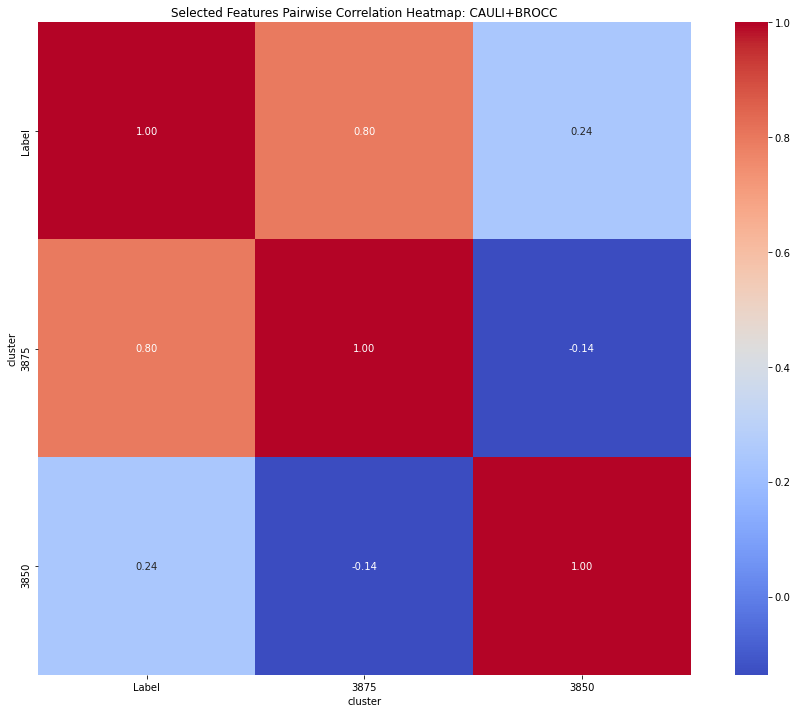

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

#gr1 = [3875, 7863, 3874,3319,7859,7864]
#gr2 = [65, 104, 193, 1141, 1185, 2054, 2382, 2915, 3096, 8547, 8991]
gr = ['Label']+[3875,3850]
corrmat = dat[gr].corr()
plt.figure(figsize=(16, 12)) # Adjust figure size if needed
sns.heatmap(
    corrmat,
    annot=True,
    cmap='coolwarm', # A common colormap for correlation heatmaps
    fmt=".2f", # Format annotations to two decimal places
    square=True # Ensure cells are square
)
plt.title('Selected Features Pairwise Correlation Heatmap: CAULI+BROCC')
plt.show()

dat[gr].to_csv('./Exp3_extract1.csv')
